In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from pathlib import Path
from collections import defaultdict
import time

In [41]:
run_to_efield = {

    # Zero-field reference
    39510: 0.0,

    # Increasing HV scan
    39511: 0.028571,
    39512: 0.057143,
    39514: 0.085714,
    39515: 0.114286,
    39516: 0.142857,
    39517: 0.171429,
    39518: 0.200000,
    39519: 0.228571,
    39521: 0.257143,
    39522: 0.285714,
    39523: 0.314286,
    39525: 0.342857,
    39526: 0.371429,
    39527: 0.400000,
    39528: 0.428571,
    39529: 0.444857,
   # 39787: 0.5, bad

    # Decreasing HV scan
    39500: 0.444857,
    39501: 0.400000,
    39502: 0.342857,
    39503: 0.285714,
    39504: 0.228571,
    39506: 0.171429,
    39507: 0.114286,
    39508: 0.057143,

    # Higher HV scan
    43380: 0.685,
    43381: 0.685,
    43383: 0.586,
    43384: 0.586,
    43386: 0.771,
    43387: 0.771,
    43389: 0.44,
    43390: 0.44,

}

# ============================================================
# Paths
# ============================================================

path_waveforms = Path("../../coincidence/selected_waveforms/20260903_121324/")

csv_files = sorted(path_waveforms.glob("fprompt_*_run_*.csv"))
print(f"Found {len(csv_files)} CSV files.")

Found 136 CSV files.


In [42]:
pattern = re.compile(
    r"^fprompt_(?P<channel>\d+)_coincidence_scan_run_"
    r"(?P<run>\d+)_(?P<date>\d{8})_(?P<time>\d{6})\.csv$"
)

sample=[]
for csv_file in csv_files:
    match = pattern.fullmatch(csv_file.name)

    if match is None:
            continue

    channel = int(match["channel"])
    run = int(match["run"])
    sample.append((channel, run, csv_file))

sample = np.array(sample)


In [48]:
file = sample[0:,2]
channel = sample[0:,0]
run = sample[0:,1]

Run 40931 not found in run_to_efield mapping.
Run 40931 not found in run_to_efield mapping.


/tmp/ipykernel_3427306/3067256047.py:36: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


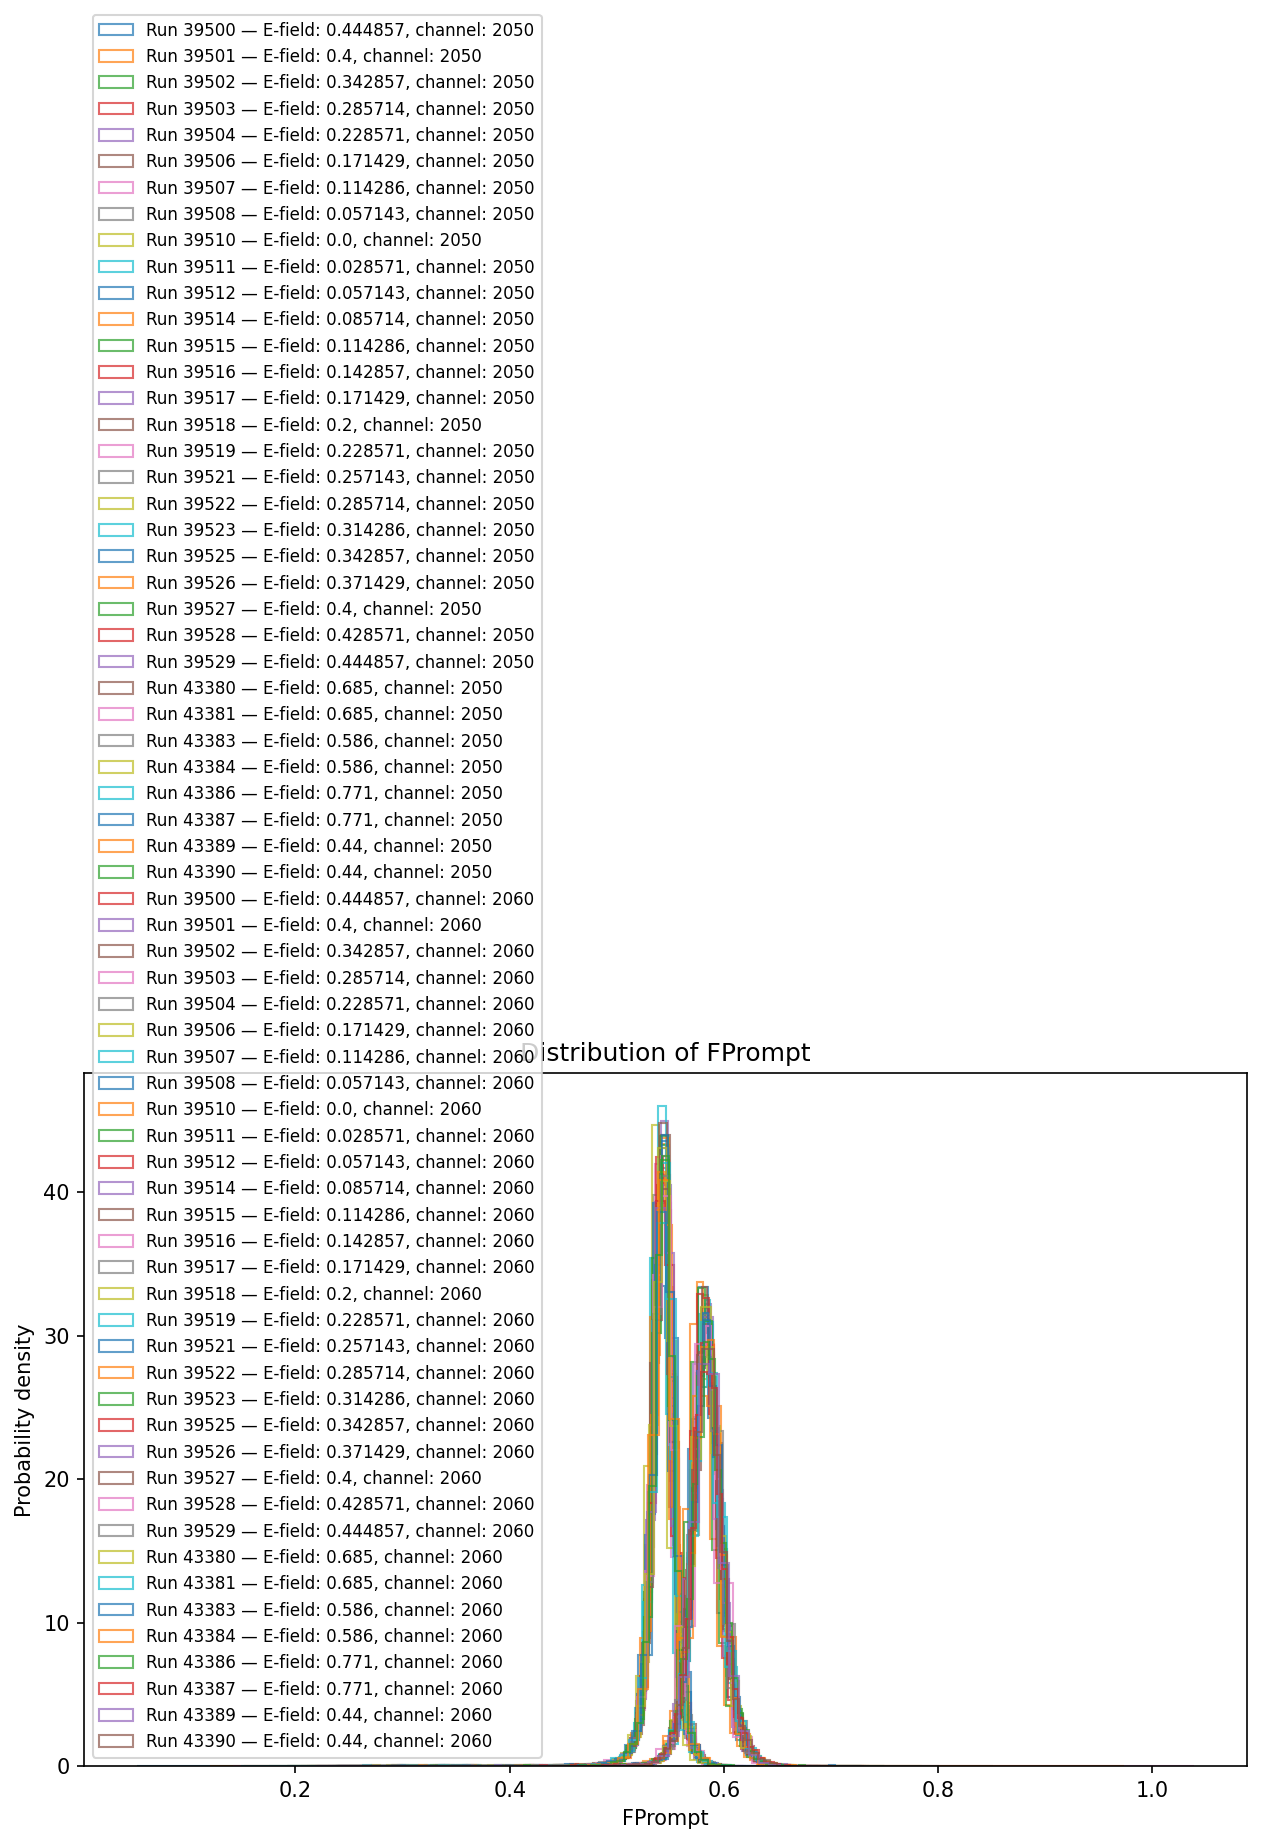

In [ ]:

selected_channels = [2060, 2050]
mask = np.isin(channel, selected_channels)

plt.figure(figsize=(10, 6), dpi=150)

for i in range(len(file)):
    if not mask[i]:
        continue

    run_number = int(run[i])

    if run_number not in run_to_efield:
        print(f"Run {run_number} not found in run_to_efield mapping.")
        continue

    efield = run_to_efield[run_number]
    df = pd.read_csv(file[i])
    fprompt = df["fprompt"].dropna()

    plt.hist(
        fprompt,
        bins=50,
        alpha=0.7,
        density=True,
        histtype="step",
        #label=(
        #    f"Run {run_number} — E-field: {efield}, "
        #    f"channel: {channel[i]}"
        #),
    )

plt.xlabel("FPrompt")
plt.ylabel("Probability density")
plt.title("Distribution of FPrompt")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()